In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

In [5]:
ds_precip = xr.open_dataset("chirps-v2.0.annual.nc")
ds_precip

<xarray.Dataset>
Dimensions:    (latitude: 2000, longitude: 7200, time: 44)
Coordinates:
  * latitude   (latitude) float32 -49.97 -49.92 -49.88 ... 49.87 49.92 49.97
  * longitude  (longitude) float32 -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * time       (time) datetime64[ns] 1981-01-01 1982-01-01 ... 2024-01-01
Data variables:
    precip     (time, latitude, longitude) float32 ...
Attributes: (12/15)
    Conventions:       CF-1.6
    title:             CHIRPS Version 2.0
    history:           created by Climate Hazards Group
    version:           Version 2.0
    date_created:      2025-01-15
    creator_name:      Pete Peterson
    ...                ...
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    comments:           time variable denotes the first day of the given year.
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pub/org/chg/products/CH...
    website:           http://chg.geog.ucsb.edu/data/chirps/index.html
    faq:               http://chg-wiki.geog.ucsb.edu/wiki/CHIRPS_FAQ

In [9]:
ds_temp= xr.open_mfdataset('C:/Users/INSPIRON/TEMP/*.nc')
ds_temp

<xarray.Dataset>
Dimensions:  (lon: 720, lat: 360, time: 636)
Coordinates:
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) datetime64[ns] 1971-01-16 1971-02-15 ... 2023-12-16
Data variables:
    tmp      (time, lat, lon) float32 dask.array<chunksize=(120, 360, 720), meta=np.ndarray>
    stn      (time, lat, lon) float64 dask.array<chunksize=(120, 360, 720), meta=np.ndarray>
    mae      (time, lat, lon) float32 dask.array<chunksize=(120, 360, 720), meta=np.ndarray>
    maea     (time, lat, lon) float32 dask.array<chunksize=(120, 360, 720), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.08 Mean Temperature
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2406270035. Data generated from:tmp.2406262226.dtb
    history:      Thu 27 Jun 01:31:07 BST 2024 : User f098 : Program makegrid...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access to these data is available to any registered CEDA user.
    contact:      support@ceda.ac.uk

In [25]:
dam_data = pd.read_excel('akosombo_data.xlsx')
dam_data

,years,data,anomaly data
0,1980.0,262.780000,9.138864
1,1981.0,259.670000,6.028864
2,1982.0,250.850000,-2.791136
3,1983.0,241.500000,-12.141136
4,1984.0,240.520000,-13.121136
5,1985.0,247.510000,-6.131136
6,1986.0,253.080000,-0.561136
7,1987.0,249.330000,-4.311136
8,1988.0,251.990000,-1.651136
9,1989.0,258.540000,4.898864


Pearson Correlation (Temp vs Dam Levels): -0.009 (p-value: 0.956)
Pearson Correlation (Precip vs Dam Levels): 0.222 (p-value: 0.153)
Spearman Correlation (Temp vs Dam Levels): -0.065 (p-value: 0.679)
Spearman Correlation (Precip vs Dam Levels): 0.254 (p-value: 0.101)


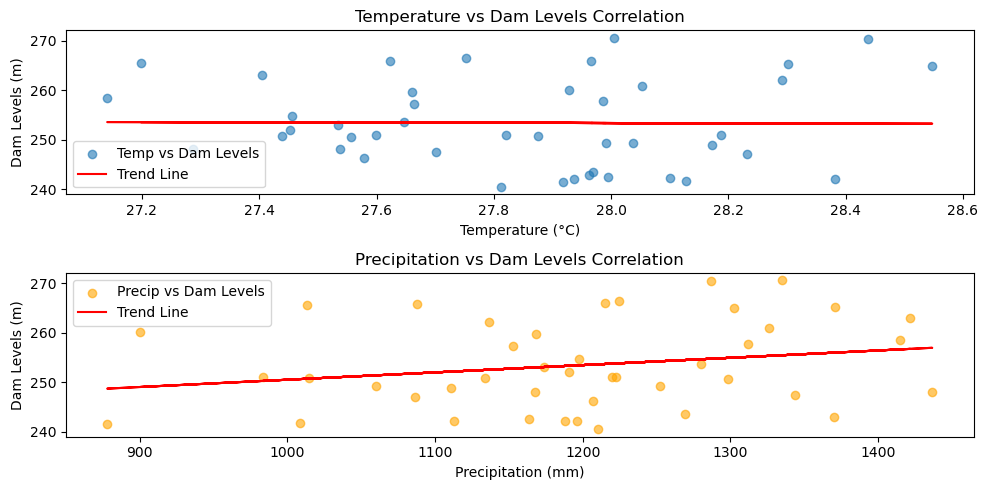

In [29]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Load the climate data (temperature and precipitation)
ds_precip = xr.open_dataset("chirps-v2.0.annual.nc")
ds_temp = xr.open_mfdataset('C:/Users/INSPIRON/TEMP/*.nc')

# Define the Volta Basin Bounding Box (coordinates)
lat_min, lat_max = 6, 11
lon_min, lon_max = -2, 1

# Select the region (Volta Basin) for both temperature and precipitation
climate_subset_precip = ds_precip.sel(
    latitude=slice(lat_min, lat_max),
    longitude=slice(lon_min, lon_max)
)

climate_subset_temp = ds_temp.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

# Compute the regional mean temperature and precipitation for the selected region
temp_volta = climate_subset_temp['tmp'].mean(dim=['lat', 'lon'])
precip_volta = climate_subset_precip['precip'].mean(dim=['latitude', 'longitude'])

# Convert time to a pandas datetime object
temp_volta = temp_volta.sel(time=slice('1981-01-01', '2023-12-31'))
precip_volta = precip_volta.sel(time=slice('1981-01-01', '2023-12-31'))

# Group the climate data by year
temp_volta_yearly = temp_volta.groupby('time.year').mean()
precip_volta_yearly = precip_volta.groupby('time.year').mean()

# Create a dataframe with the climate data
climate_df = pd.DataFrame({
    'Year': temp_volta_yearly['year'].values,
    'Temperature': temp_volta_yearly.values,
    'Precipitation': precip_volta_yearly.values
})

# Load the dam levels data (make sure to check for correct columns)
dam_data = pd.read_excel('akosombo_data.xlsx')

# Filter the dam data to only include years from 1981 to 2023
dam_data_filtered = dam_data[dam_data['years'].between(1981, 2023)]

# Merge the climate and dam levels data on the 'Year' column
merged_df = pd.merge(dam_data_filtered, climate_df, left_on="years", right_on="Year", how="inner")

# Perform correlation analysis between the climate data and dam levels
pearson_temp, p_val_temp = pearsonr(merged_df["Temperature"], merged_df["data"])  # 'data' column should hold the dam levels
pearson_precip, p_val_precip = pearsonr(merged_df["Precipitation"], merged_df["data"])

spearman_temp, p_val_spearman_temp = spearmanr(merged_df["Temperature"], merged_df["data"])
spearman_precip, p_val_spearman_precip = spearmanr(merged_df["Precipitation"], merged_df["data"])

# Print the results of the correlation analysis
print(f"Pearson Correlation (Temp vs Dam Levels): {pearson_temp:.3f} (p-value: {p_val_temp:.3f})")
print(f"Pearson Correlation (Precip vs Dam Levels): {pearson_precip:.3f} (p-value: {p_val_precip:.3f})")
print(f"Spearman Correlation (Temp vs Dam Levels): {spearman_temp:.3f} (p-value: {p_val_spearman_temp:.3f})")
print(f"Spearman Correlation (Precip vs Dam Levels): {spearman_precip:.3f} (p-value: {p_val_spearman_precip:.3f})")

# Plot the results to visualize the correlations
plt.figure(figsize=(10, 5))

# Plot for temperature vs dam levels
plt.subplot(2, 1, 1)
plt.scatter(merged_df["Temperature"], merged_df["data"], alpha=0.6, label="Temp vs Dam Levels")
m_temp, b_temp = np.polyfit(merged_df["Temperature"], merged_df["data"], 1)
plt.plot(merged_df["Temperature"], m_temp * merged_df["Temperature"] + b_temp, color="red", label="Trend Line")
plt.xlabel("Temperature (°C)")
plt.ylabel("Dam Levels (m)")
plt.title("Temperature vs Dam Levels Correlation")
plt.legend()

# Plot for precipitation vs dam levels
plt.subplot(2, 1, 2)
plt.scatter(merged_df["Precipitation"], merged_df["data"], alpha=0.6, color='orange', label="Precip vs Dam Levels")
m_precip, b_precip = np.polyfit(merged_df["Precipitation"], merged_df["data"], 1)
plt.plot(merged_df["Precipitation"], m_precip * merged_df["Precipitation"] + b_precip, color="red", label="Trend Line")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Dam Levels (m)")
plt.title("Precipitation vs Dam Levels Correlation")
plt.legend()

plt.tight_layout()
plt.show()


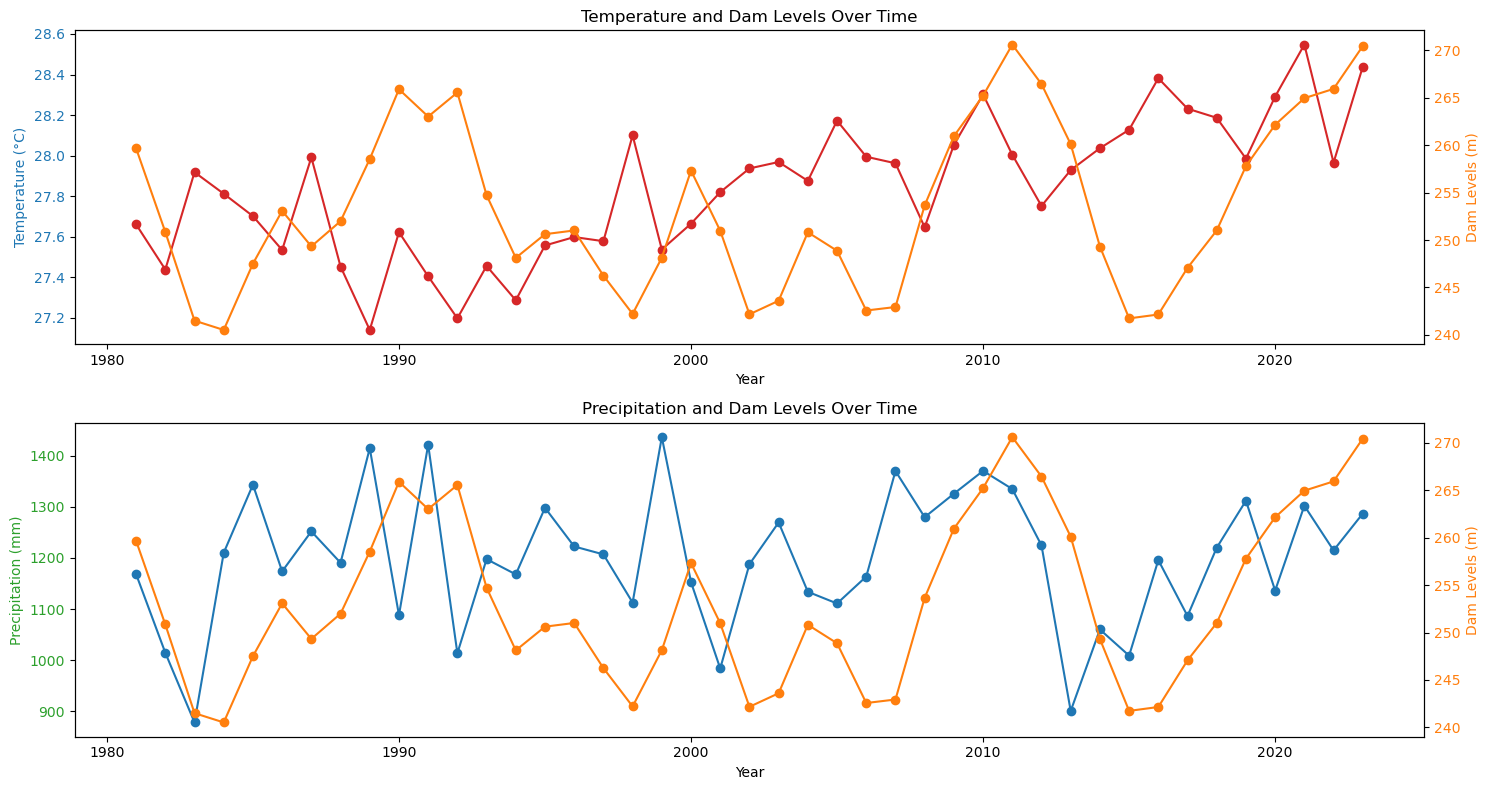

In [47]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the climate data (temperature and precipitation)
ds_precip = xr.open_dataset("chirps-v2.0.annual.nc")
ds_temp = xr.open_mfdataset('C:/Users/INSPIRON/TEMP/*.nc')

# Define the Volta Basin Bounding Box (coordinates)
lat_min, lat_max = 6, 11
lon_min, lon_max = -2, 1

# Select the region (Volta Basin) for both temperature and precipitation
climate_subset_precip = ds_precip.sel(
    latitude=slice(lat_min, lat_max),
    longitude=slice(lon_min, lon_max)
)

climate_subset_temp = ds_temp.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

# Compute the regional mean temperature and precipitation for the selected region
temp_volta = climate_subset_temp['tmp'].mean(dim=['lat', 'lon'])
precip_volta = climate_subset_precip['precip'].mean(dim=['latitude', 'longitude'])

# Convert time to a pandas datetime object
temp_volta = temp_volta.sel(time=slice('1981-01-01', '2023-12-31'))
precip_volta = precip_volta.sel(time=slice('1981-01-01', '2023-12-31'))

# Group the climate data by year
temp_volta_yearly = temp_volta.groupby('time.year').mean()
precip_volta_yearly = precip_volta.groupby('time.year').mean()

# Create a dataframe with the climate data
climate_df = pd.DataFrame({
    'Year': temp_volta_yearly['year'].values,
    'Temperature': temp_volta_yearly.values,
    'Precipitation': precip_volta_yearly.values
})

# Load the dam levels data (make sure to check for correct columns)
dam_data = pd.read_excel('akosombo_data.xlsx')

# Filter the dam data to only include years from 1981 to 2023
dam_data_filtered = dam_data[dam_data['years'].between(1981, 2023)]

# Merge the climate and dam levels data on the 'Year' column
merged_df = pd.merge(dam_data_filtered, climate_df, left_on="years", right_on="Year", how="inner")

# Plotting with two subplots
fig, ax1 = plt.subplots(2, 1, figsize=(15, 8), sharex=False)

# --- First subplot (Temperature and Dam Levels) ---
ax1[0].plot(merged_df['Year'], merged_df['Temperature'], color='tab:red', label="Temperature (°C)", marker='o')
ax1[0].set_xlabel("Year")
ax1[0].set_ylabel("Temperature (°C)", color='tab:blue')
ax1[0].tick_params(axis='y', labelcolor='tab:blue')
ax1[0].set_title("Temperature and Dam Levels Over Time")

# Create secondary y-axis for dam levels on the first subplot
ax2_0 = ax1[0].twinx()
ax2_0.plot(merged_df['Year'], merged_df['data'], color='tab:orange', label="Dam Levels (m)", marker='o')
ax2_0.set_ylabel("Dam Levels (m)", color='tab:orange')
ax2_0.tick_params(axis='y', labelcolor='tab:orange')

# --- Second subplot (Precipitation and Dam Levels) ---
ax1[1].plot(merged_df['Year'], merged_df['Precipitation'], color='tab:blue', label="Precipitation (mm)", marker='o')
ax1[1].set_xlabel("Year")
ax1[1].set_ylabel("Precipitation (mm)", color='tab:green')
ax1[1].tick_params(axis='y', labelcolor='tab:green')
ax1[1].set_title("Precipitation and Dam Levels Over Time")

# Create secondary y-axis for dam levels on the second subplot
ax2_1 = ax1[1].twinx()
ax2_1.plot(merged_df['Year'], merged_df['data'], color='tab:orange', label="Dam Levels (m)", marker='o')
ax2_1.set_ylabel("Dam Levels (m)", color='tab:orange')
ax2_1.tick_params(axis='y', labelcolor='tab:orange')

# Display the plots
plt.tight_layout()
plt.show()


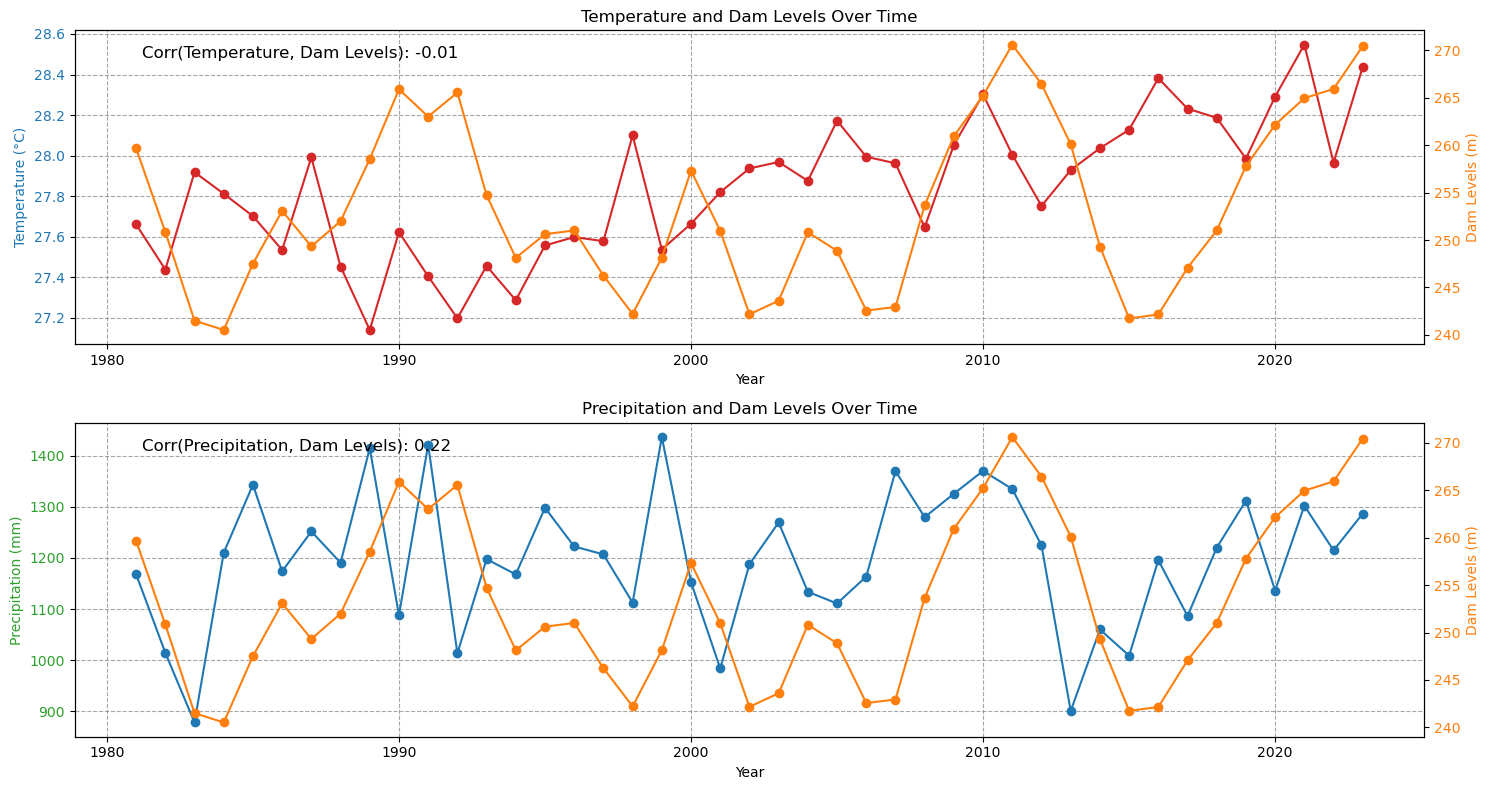

In [45]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the climate data (temperature and precipitation)
ds_precip = xr.open_dataset("chirps-v2.0.annual.nc")
ds_temp = xr.open_mfdataset('C:/Users/INSPIRON/TEMP/*.nc')

# Define the Volta Basin Bounding Box (coordinates)
lat_min, lat_max = 6, 11
lon_min, lon_max = -2, 1

# Select the region (Volta Basin) for both temperature and precipitation
climate_subset_precip = ds_precip.sel(
    latitude=slice(lat_min, lat_max),
    longitude=slice(lon_min, lon_max)
)

climate_subset_temp = ds_temp.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

# Compute the regional mean temperature and precipitation for the selected region
temp_volta = climate_subset_temp['tmp'].mean(dim=['lat', 'lon'])
precip_volta = climate_subset_precip['precip'].mean(dim=['latitude', 'longitude'])

# Convert time to a pandas datetime object
temp_volta = temp_volta.sel(time=slice('1981-01-01', '2023-12-31'))
precip_volta = precip_volta.sel(time=slice('1981-01-01', '2023-12-31'))

# Group the climate data by year
temp_volta_yearly = temp_volta.groupby('time.year').mean()
precip_volta_yearly = precip_volta.groupby('time.year').mean()

# Create a dataframe with the climate data
climate_df = pd.DataFrame({
    'Year': temp_volta_yearly['year'].values,
    'Temperature': temp_volta_yearly.values,
    'Precipitation': precip_volta_yearly.values
})

# Load the dam levels data (make sure to check for correct columns)
dam_data = pd.read_excel('akosombo_data.xlsx')

# Filter the dam data to only include years from 1981 to 2023
dam_data_filtered = dam_data[dam_data['years'].between(1981, 2023)]

# Merge the climate and dam levels data on the 'Year' column
merged_df = pd.merge(dam_data_filtered, climate_df, left_on="years", right_on="Year", how="inner")

# Calculate correlations between temperature/precipitation and dam levels
correlation_temp_dam = merged_df['Temperature'].corr(merged_df['data'])
correlation_precip_dam = merged_df['Precipitation'].corr(merged_df['data'])

# Plotting with two subplots
fig, ax1 = plt.subplots(2, 1, figsize=(15, 8), sharex=False)

# --- First subplot (Temperature and Dam Levels) ---
ax1[0].plot(merged_df['Year'], merged_df['Temperature'], color='tab:red', label="Temperature (°C)", marker='o')
ax1[0].set_xlabel("Year")
ax1[0].set_ylabel("Temperature (°C)", color='tab:blue')
ax1[0].tick_params(axis='y', labelcolor='tab:blue')
ax1[0].set_title("Temperature and Dam Levels Over Time")

# Create secondary y-axis for dam levels on the first subplot
ax2_0 = ax1[0].twinx()
ax2_0.plot(merged_df['Year'], merged_df['data'], color='tab:orange', label="Dam Levels (m)", marker='o')
ax2_0.set_ylabel("Dam Levels (m)", color='tab:orange')
ax2_0.tick_params(axis='y', labelcolor='tab:orange')

# Annotate correlation for temperature and dam levels
ax1[0].text(0.05, 0.95, f"Corr(Temperature, Dam Levels): {correlation_temp_dam:.2f}",
            transform=ax1[0].transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left')

# --- Second subplot (Precipitation and Dam Levels) ---
ax1[1].plot(merged_df['Year'], merged_df['Precipitation'], color='tab:blue', label="Precipitation (mm)", marker='o')
ax1[1].set_xlabel("Year")
ax1[1].set_ylabel("Precipitation (mm)", color='tab:green')
ax1[1].tick_params(axis='y', labelcolor='tab:green')
ax1[1].set_title("Precipitation and Dam Levels Over Time")

# Create secondary y-axis for dam levels on the second subplot
ax2_1 = ax1[1].twinx()
ax2_1.plot(merged_df['Year'], merged_df['data'], color='tab:orange', label="Dam Levels (m)", marker='o')
ax2_1.set_ylabel("Dam Levels (m)", color='tab:orange')
ax2_1.tick_params(axis='y', labelcolor='tab:orange')

# Annotate correlation for precipitation and dam levels
ax1[1].text(0.05, 0.95, f"Corr(Precipitation, Dam Levels): {correlation_precip_dam:.2f}",
            transform=ax1[1].transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left')

# Add gridlines inside the plots
for ax in ax1:
    ax.grid(True, which='both', axis='both', linestyle='--', color='gray', alpha=0.7)

# Display the plots
plt.tight_layout()
plt.show()


Lag 1 Year Lag:
  Pearson Correlation: 0.589 (p-value: 0.000)
  Spearman Correlation: 0.632 (p-value: 0.000)
-
Lag 2 Year Lag:
  Pearson Correlation: 0.499 (p-value: 0.001)
  Spearman Correlation: 0.513 (p-value: 0.001)
-
Lag 3 Year Lag:
  Pearson Correlation: 0.224 (p-value: 0.164)
  Spearman Correlation: 0.178 (p-value: 0.272)
-


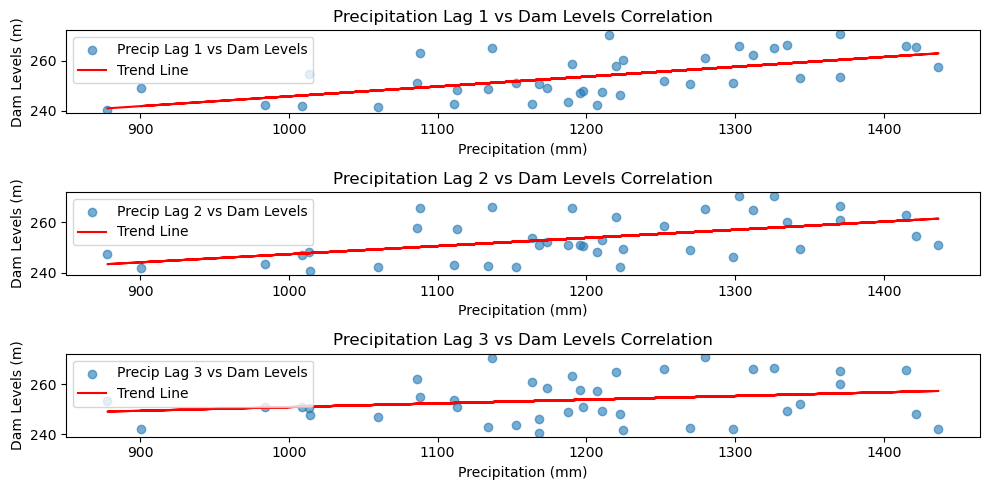

In [49]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Load the climate data (temperature and precipitation)
ds_precip = xr.open_dataset("chirps-v2.0.annual.nc")
ds_temp = xr.open_mfdataset('C:/Users/INSPIRON/TEMP/*.nc')

# Define the Volta Basin Bounding Box (coordinates)
lat_min, lat_max = 6, 11
lon_min, lon_max = -2, 1

# Select the region (Volta Basin) for both temperature and precipitation
climate_subset_precip = ds_precip.sel(
    latitude=slice(lat_min, lat_max),
    longitude=slice(lon_min, lon_max)
)

climate_subset_temp = ds_temp.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
)

# Compute the regional mean temperature and precipitation
temp_volta = climate_subset_temp['tmp'].mean(dim=['lat', 'lon'])
precip_volta = climate_subset_precip['precip'].mean(dim=['latitude', 'longitude'])

# Convert time to a pandas datetime object
temp_volta = temp_volta.sel(time=slice('1981-01-01', '2023-12-31'))
precip_volta = precip_volta.sel(time=slice('1981-01-01', '2023-12-31'))

# Group the climate data by year
temp_volta_yearly = temp_volta.groupby('time.year').mean()
precip_volta_yearly = precip_volta.groupby('time.year').mean()

# Create a dataframe with the climate data
climate_df = pd.DataFrame({
    'Year': temp_volta_yearly['year'].values,
    'Temperature': temp_volta_yearly.values,
    'Precipitation': precip_volta_yearly.values
})

# Load the dam levels data
dam_data = pd.read_excel('akosombo_data.xlsx')

# Filter the dam data to include only relevant years
dam_data_filtered = dam_data[dam_data['years'].between(1981, 2023)]

# Merge the climate and dam levels data on the 'Year' column
merged_df = pd.merge(dam_data_filtered, climate_df, left_on="years", right_on="Year", how="inner")

# Create lagged precipitation columns
for lag in range(1, 4):  # Lag of 1, 2, and 3 years
    merged_df[f'Precip_Lag_{lag}'] = merged_df['Precipitation'].shift(lag)

# Drop any NaN values that result from shifting
merged_df.dropna(inplace=True)

# Perform correlation analysis with lagged precipitation
correlation_results = {}
for lag in range(1, 4):
    pearson_corr, p_val_pearson = pearsonr(merged_df[f'Precip_Lag_{lag}'], merged_df["data"])
    spearman_corr, p_val_spearman = spearmanr(merged_df[f'Precip_Lag_{lag}'], merged_df["data"])
    correlation_results[f'Lag {lag}'] = {
        'Pearson': (pearson_corr, p_val_pearson),
        'Spearman': (spearman_corr, p_val_spearman)
    }

# Print results
for lag, values in correlation_results.items():
    print(f"{lag} Year Lag:")
    print(f"  Pearson Correlation: {values['Pearson'][0]:.3f} (p-value: {values['Pearson'][1]:.3f})")
    print(f"  Spearman Correlation: {values['Spearman'][0]:.3f} (p-value: {values['Spearman'][1]:.3f})")
    print("-")

# Plotting Precipitation Lag Effects
plt.figure(figsize=(10, 5))
for i, lag in enumerate(range(1, 4), 1):
    plt.subplot(3, 1, i)
    plt.scatter(merged_df[f'Precip_Lag_{lag}'], merged_df["data"], alpha=0.6, label=f"Precip Lag {lag} vs Dam Levels")
    m, b = np.polyfit(merged_df[f'Precip_Lag_{lag}'], merged_df["data"], 1)
    plt.plot(merged_df[f'Precip_Lag_{lag}'], m * merged_df[f'Precip_Lag_{lag}'] + b, color="red", label="Trend Line")
    plt.xlabel("Precipitation (mm)")
    plt.ylabel("Dam Levels (m)")
    plt.title(f"Precipitation Lag {lag} vs Dam Levels Correlation")
    plt.legend()

plt.tight_layout()
plt.show()
